<div style="display:flex;align-items:center;gap:14px;padding:14px 16px;border:1px solid #e5e7eb;border-radius:12px;">
<div style="font-size:28px;">📈</div>
<div>
<div style="font-size:20px;font-weight:700;">Данная стратегия подготовлена Ширяевым Егором и является выпускной end-to-end стратегией</div>
<div style="color:#555;">Исследование стратегии на рынке российских blue chips: корректировка цен, бенчмарк, риск-управление и бэктест.</div>
</div>
</div>


## Как запускать ноутбук

1. Установить зависимости.
2. Задать токен в переменной окружения `TINKOFF_TOKEN`.
3. Выполнить ноутбук сверху вниз.

```bash
export TINKOFF_TOKEN="<your_token>"
```


# Формулировка торговой гипотезы и её мотивация

**Гипотеза:** на рынке ликвидных российских акций наблюдаются устойчивые среднесрочные тренды.  
Комбинация trend-following и volatility targeting улучшает риск-профиль портфеля относительно пассивного владения.

**Ожидаемый эффект:**
- участие в направленных движениях рынка  
- снижение риска в периоды высокой волатильности  
- более стабильные доходности  

## Экономическая мотивация
- **Momentum:** активы с положительной динамикой часто продолжают движение.  
- **Кластеризация волатильности:** управление позицией через target vol стабилизирует риск.  
- **Диверсификация:** портфель ликвидных blue chips снижает специфический риск.

## Идея реализации
Стратегия использует тренд-фильтр и масштабирование позиций по целевой волатильности для получения более стабильной риск-скорректированной доходности относительно пассивного равновзвешенного портфеля.

# Критерии принятия стратегии в прод

## 1. Out-of-sample устойчивость
- стабильные результаты на walk-forward периодах  
- контролируемый уровень просадок  

## 2. Устойчивость к издержкам
- стратегия остаётся жизнеспособной при реалистичных комиссиях и спрэдах  
- результаты не «схлопываются» при увеличении cost bps  

## 3. Робастность параметров
- небольшие изменения lookback/vol-target не должны ломать стратегию  
- метрики риска и доходности остаются стабильными  

## 4. Контроль риска
- ограниченный max drawdown  
- стабильная волатильность портфеля  
- диверсификация между активами  

## 5. Реализуемость
- используются ликвидные инструменты  
- разумная частота ребалансировки  


## Архитектура и безопасность (замечание к прод-версии)

В этом ноутбуке логика исследования собрана в одном месте (загрузка данных, обработка, бэктест, отчёты), что удобно для демонстрации. Для `prod`-реализации код рекомендуется вынести в отдельные модули (`data / processing / backtest / reporting`), параметры хранить в конфиге, а токен Tinkoff API — только в переменной окружения `TINKOFF_TOKEN`.

> В этой версии ноутбука захардкоженный токен удалён: данные загружаются только при наличии `TINKOFF_TOKEN` в окружении.


In [2]:
# loggings utils
import asyncio
import functools

from loguru import logger


# wrapper for logging function entry and exit
def _log_function_call(*, when_entered=True, when_exited=True, level="DEBUG"):
    def wrapper(func):
        @functools.wraps(func)
        def wrapped(*args, **kwargs):
            name = func.__name__
            logger_ = logger.opt(depth=1)

            if when_entered:
                logger_.log(
                    level,
                    "Entering '{}' (args={}, kwargs={})",
                    name,
                    args,
                    kwargs,
                )

            try:
                result = func(*args, **kwargs)
            except Exception as error:
                if when_exited:
                    logger_.log(
                        level,
                        "Exiting '{}' (with exception: {})",
                        name,
                        str(error),
                    )
                raise

            if when_exited:
                logger_.log(level, "Exiting '{}' (result={})", name, result)

            return result

        # some magic for async functions
        if asyncio.iscoroutinefunction(func):
            return functools.update_wrapper(asyncio.coroutine(wrapped), func)

        return functools.update_wrapper(wrapped, func)

    return wrapper

In [3]:
# converter utils for tinkoff classes
import datetime
import json
import types
from dataclasses import fields, is_dataclass
from decimal import Decimal
from typing import Any
import pandas as pd
from tinkoff.invest import utils
from tinkoff.invest.schemas import (
    MoneyValue,
    Quotation,
    TradeDirection,
)


@_log_function_call(level="TRACE")
def _dataclasses_to_dict(obj: Any, dict_factory=dict) -> Any:
    if isinstance(obj, types.GeneratorType):
        return _dataclasses_to_dict([*obj])
    if isinstance(obj, datetime.datetime):
        return _datetime_to_timestamp(obj)
    if isinstance(obj, MoneyValue):
        return _money_value_to_float(obj)
    if isinstance(obj, Quotation):
        return _quotation_to_float(obj)
    if isinstance(obj, TradeDirection):
        return int(obj)
    if is_dataclass(obj):
        return _dataclass_to_dict(obj, dict_factory=dict_factory)
    if isinstance(obj, tuple) and hasattr(obj, "_fields"):
        return type(obj)(*[_dataclasses_to_dict(v, dict_factory) for v in obj])
    if isinstance(obj, (list, tuple)):
        return type(obj)(_dataclasses_to_dict(v, dict_factory) for v in obj)
    if isinstance(obj, dict):
        return type(obj)(
            (_dataclasses_to_dict(k), _dataclasses_to_dict(v))
            for k, v in obj.items()
            if v is not None
        )

    return obj


@_log_function_call(level="TRACE")
def _dataclass_to_dict(dataclass, dict_factory=dict) -> dict:
    result = []
    for field in fields(dataclass):
        value = _dataclasses_to_dict(
            getattr(dataclass, field.name),
            dict_factory,
        )
        result.append((field.name, value))

    return dict_factory(result)


@_log_function_call(level="TRACE")
def _datetime_to_timestamp(datetime_: datetime.datetime):
    if datetime_.hour == 0 and datetime_.minute == 0:
        return pd.Timestamp(datetime_.replace(tzinfo=None))

    return pd.Timestamp(datetime_.astimezone(tz=None).replace(tzinfo=None))


@_log_function_call(level="TRACE")
def _money_value_to_float(money_value: MoneyValue) -> float:
    fractional = money_value.nano / Decimal("10e8")
    return float(Decimal(money_value.units) + fractional)


@_log_function_call(level="TRACE")
def _quotation_to_float(quotation: Quotation) -> float:
    return float(utils.quotation_to_decimal(quotation))


@_log_function_call(level="TRACE")
def _float_to_quotation(float_: float):
    return utils.decimal_to_quotation(Decimal(float_))

In [4]:
# sync methods
import functools
import math
import time
from typing import List, Optional
import warnings

import aiometer
import numpy as np
from joblib import Parallel, delayed
from loguru import logger
from tinkoff.invest import (
    AsyncClient,
    CandleInterval,
    Client,
)


warnings.filterwarnings("ignore", category=DeprecationWarning)

# Token is read from environment variable (do not hardcode secrets in notebook)
import os
TOKEN = os.getenv("TINKOFF_TOKEN")
if not TOKEN:
    raise RuntimeError("Set TINKOFF_TOKEN in environment before running the data loading cells.")


@_log_function_call()
def _get_close_prices_sync(
    figis: List[str],
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    interval: CandleInterval = CandleInterval.CANDLE_INTERVAL_DAY,
    is_complete: bool = True,
    token: str = TOKEN,
) -> pd.DataFrame:
    prices = _get_prices_sync(
        figis=[figi for figi in figis],
        start_date=start_date,
        end_date=end_date,
        interval=interval,
        is_complete=is_complete,
        token=token,
    )
    # please, check `pd.pivot` docs
    return (
        prices[["time", "close", "figi"]]
        .pivot(index="time", columns="figi", values="close")
    )

@_log_function_call()
def _get_prices_sync(
    figis: List[str],
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    interval: CandleInterval = CandleInterval.CANDLE_INTERVAL_DAY,
    is_complete: bool = True,
    token: str = TOKEN,
) -> pd.DataFrame:
    return pd.concat([
        _get_prices_for_sync(
            figi,
            start_date,
            end_date,
            interval,
            is_complete,
            token,
        )
        for figi in figis]
    )


@_log_function_call()
def _get_prices_for_sync(
    figi: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    interval: CandleInterval = CandleInterval.CANDLE_INTERVAL_DAY,
    is_complete: bool = True,
    token: str = TOKEN,
):
    with Client(token) as client:
        raw_candles = _dataclasses_to_dict(
            client.get_all_candles(
                figi=figi,
                from_=start_date,
                to=end_date,
                interval=interval,
            )
        )

    # please, check `pd.assign` docs
    prices = pd.DataFrame(raw_candles).assign(figi=figi)
    if prices.empty:
        logger.warning(f"No candles for {figi} ({start_date}-{end_date})")
        return prices

    if "is_complete" in prices.columns and is_complete:
        prices = prices.query("is_complete").copy()

    if interval == CandleInterval.CANDLE_INTERVAL_DAY:
        prices.time = prices.time.map(pd.Timestamp.normalize)

    return prices


In [5]:
import time
import functools
import inspect

def _log_function_call(level="DEBUG"):
    def deco(func):
        is_coro = inspect.iscoroutinefunction(func)

        @functools.wraps(func)
        async def aw(*args, **kwargs):
            t0 = time.perf_counter()
            logger.log(level, f"Entering '{func.__name__}'")
            try:
                return await func(*args, **kwargs)
            finally:
                logger.log(level, f"Exiting '{func.__name__}' ({time.perf_counter()-t0:.3f}s)")

        @functools.wraps(func)
        def sw(*args, **kwargs):
            t0 = time.perf_counter()
            logger.log(level, f"Entering '{func.__name__}'")
            try:
                return func(*args, **kwargs)
            finally:
                logger.log(level, f"Exiting '{func.__name__}' ({time.perf_counter()-t0:.3f}s)")

        return aw if is_coro else sw
    return deco


In [6]:
# dividends loading
import functools
import math
import time
from typing import List, Optional

import aiometer
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from loguru import logger
from tinkoff.invest import AsyncClient, Client


@_log_function_call()
async def _get_dividends_async(
    figis: List[str],
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    max_per_second: Optional[float] = None,
    token: str = TOKEN,
) -> pd.DataFrame:
    if max_per_second is None:
        max_per_second = await _get_max_requests_per_second()

    jobs = [
        functools.partial(
            _get_dividends_for_async,
            figi,
            start_date,
            end_date,
            token,
        )
        for figi in figis
    ]
    raw_dividends = await aiometer.run_all(jobs, max_per_second=max_per_second)
    dividends = pd.concat(raw_dividends)

    return dividends


@_log_function_call()
def _get_dividends_sync(
    figis: List[str],
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    token: str = TOKEN,
) -> pd.DataFrame:
    return pd.concat([
        _get_dividends_for_sync(
            figi, start_date, end_date, token
        )
        for figi in figis
    ])


@_log_function_call()
async def _get_dividends_for_async(
    figi: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    token: str = TOKEN,
) -> pd.DataFrame:
    async with AsyncClient(token) as client:
        dividends = pd.json_normalize(
            _dataclasses_to_dict(
                (await client.instruments.get_dividends(
                    figi=figi,
                    from_=start_date,
                    to=end_date,
                )).dividends,
            )
        ).assign(figi=figi)

    if "dividend_type" in dividends.columns:
        dividends = dividends.query('dividend_type != "Cancelled"')

    if "payment_date" in dividends.columns:
        dividends = dividends.query("@end_date > payment_date > @start_date")

    return dividends


@_log_function_call()
def _get_dividends_for_sync(
    figi: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    token: str = TOKEN,
) -> pd.DataFrame:
    with Client(token) as client:
        dividends = pd.json_normalize(
            _dataclasses_to_dict(
                client.instruments.get_dividends(
                    figi=figi,
                    from_=start_date,
                    to=end_date,
                ).dividends,
            )
        ).assign(figi=figi)

    if "dividend_type" in dividends.columns:
        dividends = dividends.query('dividend_type != "Cancelled"')

    if "payment_date" in dividends.columns:
        dividends = dividends.query("@end_date > payment_date > @start_date")

    return dividends

In [7]:
from loguru import logger
logger.remove()
logger.add(lambda msg: None, level="WARNING") 


1

In [8]:
blue_chips_prices = _get_prices_sync(
     figis=[
        "BBG004730N88",  # SBER - Сбербанк 
        "BBG004730RP0",  # GAZP - ГАЗПРОМ ао  
        "BBG004731032",  # LKOH - ЛУКОИЛ
        "BBG004RVFFC0",  # TATN - Татнефть Зао
        "BBG004730ZJ9",  # VTBR - ВТБ
        "BBG00475KKY8",  # NVTK - Новатэк ао
        "BBG004731489",  # GMKN - ГМКНорНик
        "BBG000R607Y3",  # PLZL - Полюс 
        "BBG004731354",  # ROSN - Роснефть 
        "BBG0047315D0",  # SNGS - Сургутнефтегаз
        "BBG004730JJ5",  # MOEX - МосБиржа 
        "BBG00475K6C3",  # CHMF - Северсталь-ао
        "BBG004S681B4"   # NLMK - НЛМК ао
    ], 
    start_date=pd.Timestamp('2020-01-01'),
    end_date=pd.Timestamp('2025-01-01'),
)
blue_chips_prices

,open,high,low,close,volume,time,is_complete,candle_source,figi
0,255.99,258.19,253.70,255.00,35851840,2020-01-03,True,1,BBG004730N88
1,254.75,254.84,251.40,253.90,22348300,2020-01-06,True,1,BBG004730N88
2,253.57,259.15,253.03,259.15,40817240,2020-01-08,True,1,BBG004730N88
3,259.40,261.76,257.01,257.99,38329020,2020-01-09,True,1,BBG004730N88
4,257.86,259.25,256.88,258.19,18851390,2020-01-10,True,1,BBG004730N88
...,...,...,...,...,...,...,...,...,...
1244,133.08,136.20,131.80,135.30,1415383,2024-12-25,True,1,BBG004S681B4
1245,135.58,137.58,133.44,133.78,1303639,2024-12-26,True,1,BBG004S681B4
1246,133.84,135.50,132.72,134.86,882824,2024-12-27,True,1,BBG004S681B4
1247,135.02,140.30,135.02,139.62,939827,2024-12-28,True,1,BBG004S681B4


In [9]:
blue_chips_close_prices = blue_chips_prices.pivot_table(
    index='time',
    columns='figi',
    values='close',
)
blue_chips_close_prices

figi,BBG000R607Y3,BBG004730JJ5,BBG004730N88,BBG004730RP0,BBG004730ZJ9,BBG004731032,BBG004731354,BBG004731489,BBG0047315D0,BBG00475K6C3,BBG00475KKY8,BBG004RVFFC0,BBG004S681B4
time,,,,,,,,,,,,,
2020-01-03,728.6,107.18,255.00,259.00,231.200,6294.0,456.90,194.48,51.375,945.8,1264.0,776.7,144.50
2020-01-06,742.2,108.03,253.90,256.55,230.550,6382.0,455.60,195.88,52.200,929.0,1271.0,776.0,141.94
2020-01-08,746.8,110.84,259.15,255.79,232.625,6496.5,452.00,198.50,52.000,927.2,1325.4,788.0,139.50
2020-01-09,732.6,111.00,257.99,254.07,235.375,6430.0,460.20,198.38,53.645,928.2,1339.4,806.7,141.96
2020-01-10,722.0,112.99,258.19,251.90,238.000,6490.0,473.50,198.78,54.000,937.4,1306.8,801.0,143.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,1397.4,196.61,271.69,128.11,76.530,6987.5,581.95,108.00,23.655,1161.8,929.4,629.2,135.30
2024-12-26,1400.2,194.08,269.56,126.89,75.740,7003.0,579.10,109.66,24.000,1174.4,949.8,630.9,133.78
2024-12-27,1414.0,192.45,271.20,127.79,76.490,6990.5,591.00,111.04,23.870,1186.2,949.2,635.8,134.86


In [10]:
# Выгружаем дивиденды
blue_chips_dividends =  _get_dividends_sync(
     figis=[
        "BBG004730N88",  # SBER - Сбербанк 
        "BBG004730RP0",  # GAZP - ГАЗПРОМ ао  
        "BBG004731032",  # LKOH - ЛУКОИЛ
        "BBG004RVFFC0",  # TATN - Татнефть Зао
        "BBG004730ZJ9",  # VTBR - ВТБ
        "BBG00475KKY8",  # NVTK - Новатэк ао
        "BBG004731489",  # GMKN - ГМКНорНик
        "BBG000R607Y3",  # PLZL - Полюс 
        "BBG004731354",  # ROSN - Роснефть 
        "BBG0047315D0",  # SNGS - Сургутнефтегаз
        "BBG004730JJ5",  # MOEX - МосБиржа 
        "BBG00475K6C3",  # CHMF - Северсталь-ао
        "BBG004S681B4"   # NLMK - НЛМК ао
    ], 
    start_date=pd.Timestamp('2020-01-01'),
    end_date=pd.Timestamp('2025-01-01'),
)
blue_chips_dividends

,dividend_net,payment_date,declared_date,last_buy_date,dividend_type,record_date,regularity,close_price,yield_value,created_at,figi
0,33.30,2024-07-21,2024-07-01,2024-07-10,,2024-07-11,Quarter,315.50,10.44,2024-04-23 12:45:22.287573,BBG004730N88
1,25.00,2023-06-16,2023-04-21,2023-05-10,,2023-05-11,,238.90,10.46,2023-05-11 10:03:30.109944,BBG004730N88
2,18.70,2021-05-26,2021-03-19,2021-05-11,,2021-05-12,Annual,319.97,5.84,2021-07-28 13:50:31.391457,BBG004730N88
3,18.70,2020-10-19,2020-03-17,2020-10-02,,2020-10-05,Annual,228.85,8.17,2021-07-28 13:50:31.391457,BBG004730N88
0,51.03,2022-11-15,2022-09-30,2022-10-10,,2022-10-11,,201.40,25.34,2022-11-11 05:07:37.654754,BBG004730RP0
...,...,...,...,...,...,...,...,...,...,...,...
5,6.43,2021-02-10,2020-12-18,2020-12-28,,2020-12-29,,223.80,2.87,2021-01-29 05:00:40.432396,BBG004S681B4
6,4.75,2020-11-17,2020-09-25,2020-10-09,,2020-10-12,,174.34,2.72,2020-12-08 14:05:33.625739,BBG004S681B4
7,3.21,2020-08-17,2020-06-30,2020-07-10,,2020-07-13,,139.96,2.29,2020-12-08 14:05:33.625739,BBG004S681B4
8,3.12,2020-07-15,2020-05-29,2020-06-08,,2020-06-09,,142.00,2.20,2020-12-08 14:05:33.625739,BBG004S681B4


In [11]:
# Маппинг FIGI -> тикер (для удобства дальнейшей работы)
figi_to_ticker = {
    "BBG004730N88": "SBER",
    "BBG004730RP0": "GAZP",
    "BBG004731032": "LKOH",
    "BBG004RVFFC0": "TATN",
    "BBG004730ZJ9": "VTBR",
    "BBG00475KKY8": "NVTK",
    "BBG004731489": "GMKN",
    "BBG000R607Y3": "PLZL",
    "BBG004731354": "ROSN",
    "BBG0047315D0": "SNGS",
    "BBG004731015": "MOEX",
    "BBG00475K6C3": "CHMF",
    "BBG004S681B4": "NLMK",
}

# Добавляем тикеры в дивиденды
blue_chips_dividends["ticker"] = blue_chips_dividends["figi"].map(figi_to_ticker)

blue_chips_close_prices = blue_chips_close_prices.rename(columns=figi_to_ticker)


In [12]:
split_map = {
    "PLZL": ("2024-12-20", 10),        # PLZL 1:10
    "VTBR": ("2024-07-15", 1/0.0002), # VTBR 1:50 000
    "GMKN": ("2021-10-04", 100),      # GMKN 100:1
}


## Additive adjustment цен на дивиденды

### Зачем это нужно
Для корректного расчёта доходностей без реинвестирования дивидендов нужно убрать из исторических цен эффект будущих выплат.  
Иначе на дивидендных отсечках возникают искусственные ценовые разрывы, которые искажают доходности и сигналы стратегии.

---

### Математическая идея

Обозначим:

- $P_t$ — цена закрытия в момент $t$
- $D_t$ — дивиденд на акцию
- $P_t^{adj}$ — скорректированная цена

Тогда аддитивная корректировка задаётся как:

$$
P_t^{adj} = P_t - \sum_{u>t} D_u
$$

То есть из цены в момент $t$ вычитается сумма всех будущих дивидендов.


>  Хочется добавить, что при большом желании можно сверять свой эджаст с yfinance, но стоит упомянуть про разницу в методах учета дивидендов, так что хоть и разница в полученных коректировках может сразу отпугнуть, но стоит оценивать именно pct_change(), а не абсолютные значения.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

@_log_function_call()
def _get_additively_adjusted_prices(
    prices: pd.DataFrame,
    dividends: pd.DataFrame,
    split_map: dict,
) -> pd.DataFrame:
    """Аддитивная корректировка цен на дивиденды (+ учет сплитов через split_map).
    """

    split_map_parsed = {
        ticker: (pd.to_datetime(date), ratio)
        for ticker, (date, ratio) in split_map.items()
    }

    dividends_adj = dividends.copy()

    for ticker, (split_date, ratio) in split_map_parsed.items():
        mask = (dividends_adj["ticker"] == ticker) & (dividends_adj["last_buy_date"] < split_date)
        dividends_adj.loc[mask, "dividend_net"] /= ratio

    cumulative_dividends = (
        dividends_adj.pivot_table(
            index="last_buy_date",
            columns="ticker",
            values="dividend_net",
        )
        .reindex(index=prices.index, columns=prices.columns)
        .fillna(0)
        .sort_index(ascending=False)
        .cumsum()
        .ffill()
        .sort_index(ascending=True)
    )

    return prices.subtract(cumulative_dividends).dropna(how="all")


In [14]:
blue_chips_prices_adjustment_nan = _get_additively_adjusted_prices(
    prices=blue_chips_close_prices,
    dividends=blue_chips_dividends,
    split_map=split_map,
)
blue_chips_prices_adjustment = (
    blue_chips_prices_adjustment_nan
    .sort_index()
    .ffill()
    .dropna(axis=1, how="any")
)


In [15]:
blue_chips_prices_adjustment.head()

figi,PLZL,BBG004730JJ5,SBER,GAZP,VTBR,LKOH,ROSN,GMKN,SNGS,CHMF,NVTK,TATN,NLMK
time,,,,,,,,,,,,,
2020-01-03,601.626,107.18,159.30,180.18,231.197827,3051.5,310.16,169.874823,47.575,459.29,919.23,528.44,56.43
2020-01-06,615.226,108.03,158.20,177.73,230.547827,3139.5,308.86,171.274823,48.400,442.49,926.23,527.74,53.87
2020-01-08,619.826,110.84,163.45,176.97,232.622827,3254.0,305.26,173.894823,48.200,440.69,980.63,539.74,51.43
2020-01-09,605.626,111.00,162.29,175.25,235.372827,3187.5,313.46,173.774823,49.845,441.69,994.63,558.44,57.11
2020-01-10,595.026,112.99,162.49,173.08,237.997827,3247.5,326.76,174.174823,50.200,450.89,962.03,552.74,58.77


In [16]:
INITIAL_CAPITAL = 10_000_000

px = blue_chips_prices_adjustment.sort_index().copy()

px = px.dropna(axis=1, how="all")

first_valid = {c: px[c].first_valid_index() for c in px.columns}
start_date = max(d for d in first_valid.values() if d is not None)

px = px.loc[start_date:].copy()
px = px.ffill()                      
px = px.dropna(axis=1, how="any")    

assets = list(px.columns)
n = len(assets)

w = pd.Series(1.0 / n, index=assets, name="weight")
p0 = px.iloc[0].rename("price_0")

capital_per_asset = INITIAL_CAPITAL / n
shares = (capital_per_asset / p0).rename("shares")

tbl = pd.concat([w, p0, shares], axis=1)
tbl["capital_alloc"] = tbl["shares"] * tbl["price_0"]
tbl = tbl.sort_index() 



portfolio_value = (px.mul(shares, axis=1)).sum(axis=1).rename("portfolio_value")
portfolio_returns = portfolio_value.pct_change().dropna().rename("portfolio_returns")

# EDA и прозрачность данных

Ниже — быстрый обзор данных и базовые диагностические графики распределения, QQ-plot, корреляции

px shape: (1249, 13) | start: 2020-01-03 | end: 2024-12-30


figi,PLZL,BBG004730JJ5,SBER,GAZP,VTBR,LKOH,ROSN,GMKN,SNGS,CHMF,NVTK,TATN,NLMK
time,,,,,,,,,,,,,
2020-01-03,601.626,107.18,159.30,180.18,231.197827,3051.5,310.16,169.874823,47.575,459.29,919.23,528.44,56.43
2020-01-06,615.226,108.03,158.20,177.73,230.547827,3139.5,308.86,171.274823,48.400,442.49,926.23,527.74,53.87
2020-01-08,619.826,110.84,163.45,176.97,232.622827,3254.0,305.26,173.894823,48.200,440.69,980.63,539.74,51.43
2020-01-09,605.626,111.00,162.29,175.25,235.372827,3187.5,313.46,173.774823,49.845,441.69,994.63,558.44,57.11
2020-01-10,595.026,112.99,162.49,173.08,237.997827,3247.5,326.76,174.174823,50.200,450.89,962.03,552.74,58.77


figi,PLZL,BBG004730JJ5,SBER,GAZP,VTBR,LKOH,ROSN,GMKN,SNGS,CHMF,NVTK,TATN,NLMK
time,,,,,,,,,,,,,
2024-12-25,1397.4,196.61,271.69,128.11,76.53,6987.5,581.95,108.00,23.655,1161.8,929.4,629.2,135.30
2024-12-26,1400.2,194.08,269.56,126.89,75.74,7003.0,579.10,109.66,24.000,1174.4,949.8,630.9,133.78
2024-12-27,1414.0,192.45,271.20,127.79,76.49,6990.5,591.00,111.04,23.870,1186.2,949.2,635.8,134.86
2024-12-28,1392.6,192.61,272.83,129.60,78.09,6998.0,596.00,113.80,24.115,1232.2,951.8,652.4,139.62
2024-12-30,1398.2,199.22,279.43,133.12,80.03,7235.0,606.05,115.50,24.980,1337.4,996.0,688.9,147.78


asset_ret shape: (1248, 13)


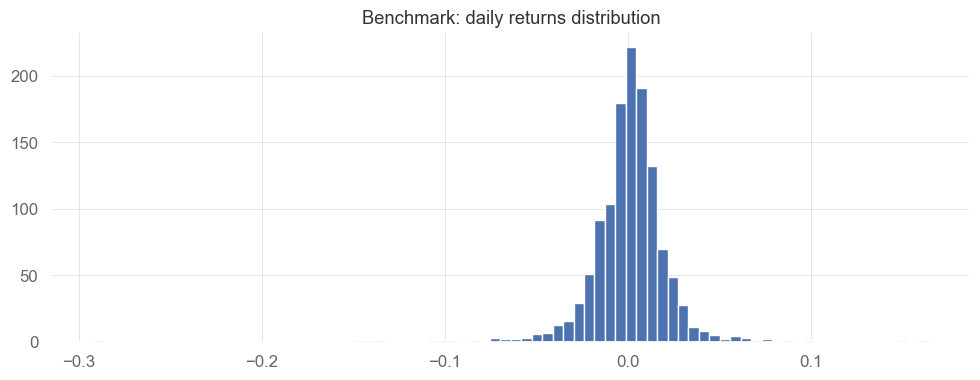

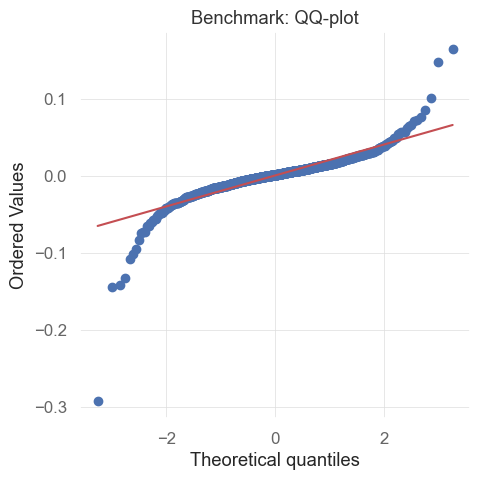

In [39]:
import numpy as np
import matplotlib.pyplot as plt

print("px shape:", px.shape, "| start:", px.index.min().date(), "| end:", px.index.max().date())
display(px.head())
display(px.tail())

asset_ret = px.pct_change().dropna(how="all")
print("asset_ret shape:", asset_ret.shape)

r = portfolio_returns.dropna()

plt.figure(figsize=(10,4))
plt.hist(r, bins=80)
plt.title("Benchmark: daily returns distribution")
plt.tight_layout()
plt.show()

try:
    from scipy import stats
    plt.figure(figsize=(5,5))
    stats.probplot(r.values, dist="norm", plot=plt)
    plt.title("Benchmark: QQ-plot")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("QQ-plot skipped (scipy not available):", e)


## Дополнительная EDA: корреляции активов

Ниже — более удобный взгляд на корреляции: кластеризация (если доступна `scipy`) и список наиболее коррелирующих пар.

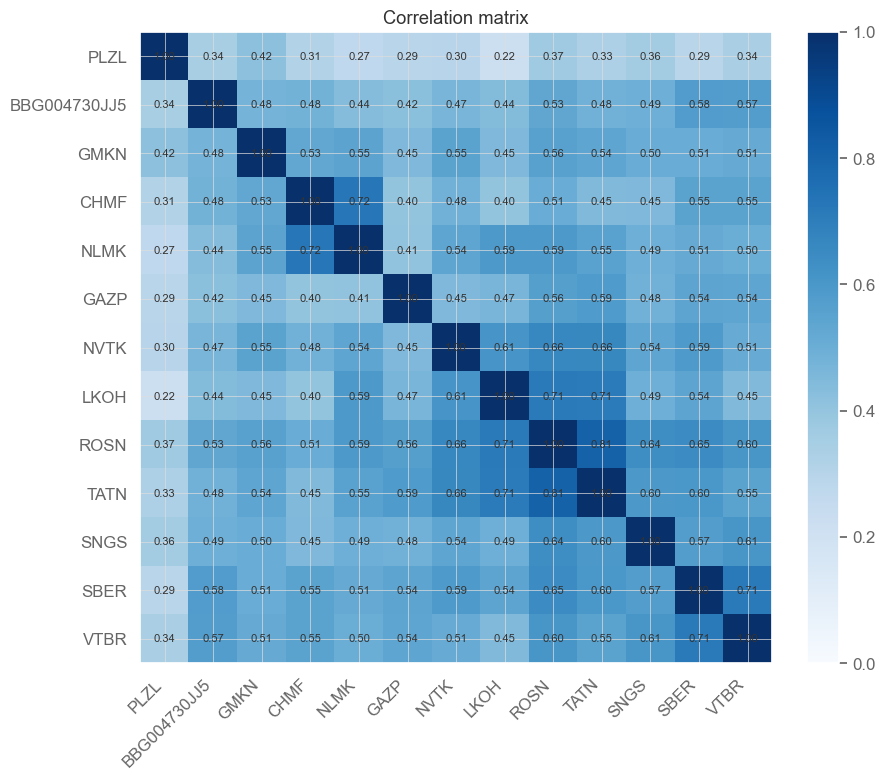

In [30]:
# Корреляции активов: heatmap (в ячейках — число)
import numpy as np
import matplotlib.pyplot as plt

corr = asset_ret.corr().abs()

# Пытаемся упорядочить активы кластеризацией (если доступна scipy)
order = list(range(len(corr.columns)))
try:
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform

    dist = 1 - corr
    Z = linkage(squareform(dist.values, checks=False), method="average")
    order = leaves_list(Z)
except Exception:
    pass

corr_ord = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_ord.values, cmap="Blues", vmin=0, vmax=1)

ax.set_title("Correlation matrix")
ax.set_xticks(range(len(corr_ord.columns)))
ax.set_yticks(range(len(corr_ord.index)))
ax.set_xticklabels(corr_ord.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_ord.index)


vals = corr_ord.values
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# Смысл стратегии

Идея: взять **базовый бенчмарк (равновзвешенный портфель)** и наложить поверх него простые, интерпретируемые правила управления риском:

1. **Тренд‑фильтр**: если equity бенчмарка выше своей скользящей средней, держим риск; если ниже — снижаем/выходим в кэш.
2. **Vol‑target**: масштабируем экспозицию так, чтобы поддерживать заданную годовую волатильность (таргет волы).
3. **Комиссии/издержки**: учитываем стоимость ребалансировок через штраф за изменение экспозиции.
4. **Кэш‑доходность**: в кэше начисляется фиксированная годовая ставка (упрощение).

Это даёт стратегию, которая часто жертвует частью апсайда в сильных трендах, но стремится улучшить **просадки** и **стабильность риска**.


Strategy returns: (1248,) | 2020-01-06 -> 2024-12-30
Time in market (mean exposure>0): 0.5681089743589743
Ann turnover proxy (|Δexposure|): 1.1509615384615388


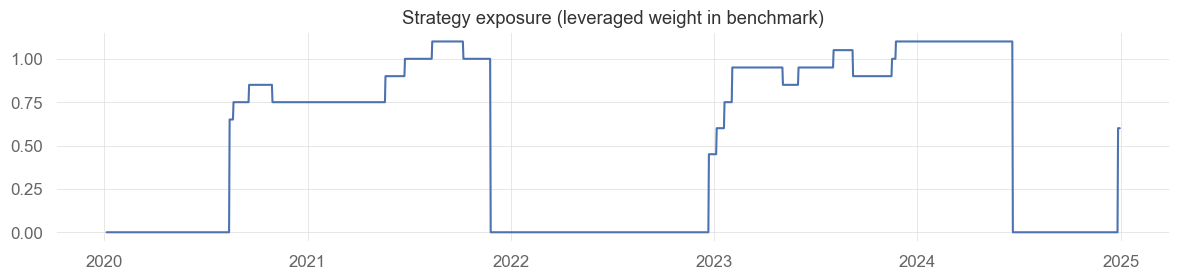

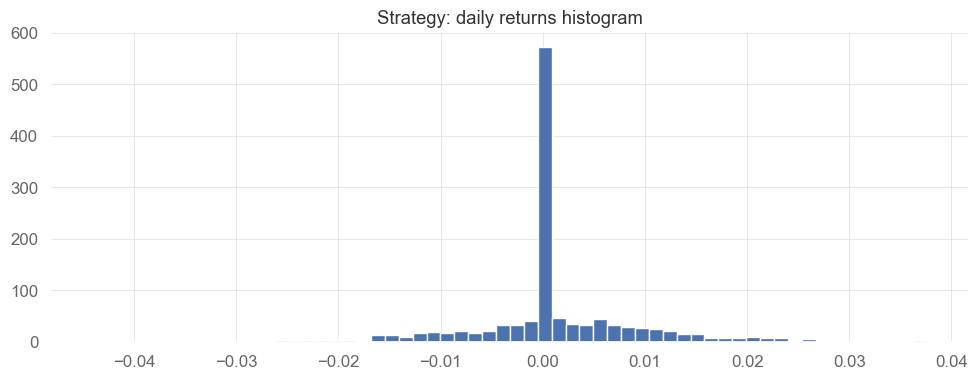


== QS: Benchmark ==
                     Strategy
-------------------  ----------
Start Period         2020-01-06
End Period           2024-12-30
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    57.46%
CAGR﹪               9.6%

Sharpe               0.44
Prob. Sharpe Ratio   83.02%
Sortino              0.58
Sortino/√2           0.41
Omega                1.09

Max Drawdown         -65.93%
Max DD Date          2022-10-07
Max DD Period Start  2021-10-20
Max DD Period End    2024-04-10
Longest DD Days      904

Gain/Pain Ratio      0.09
Gain/Pain (1M)       0.46

Payoff Ratio         0.9
Profit Factor        1.09
Common Sense Ratio   1.11
CPC Index            0.54
Tail Ratio           1.01
Outlier Win Ratio    4.29
Outlier Loss Ratio   4.33

MTD                  14.99%
3M                   4.77%
6M                   -2.76%
YTD                  4.99%
1Y                   4.99%
3Y (ann.)            0.9%
5Y (ann.)            9.34%
10Y (ann.)           9.6%
All-time 

In [31]:
qs.extend_pandas()
ANN = 252

class VolTargetTrendStrategy:
    """
    Стратегия поверх base returns (bench_ret):
      - тренд-фильтр: equity > MA(equity)
      - vol-target: exposure = target_vol / realized_vol
      - кэш: cash_ann
      - costs: cost_bps * |Δexposure|
    """
    def __init__(
        self,
        target_vol: float = 0.18,   # целевая годовая вола стратегии
        ma_window: int = 150,       # MA по equity
        vol_lookback: int = 63,     # окно realized vol (в днях)
        max_lev: float = 1.2,       # cap на экспозицию
        cash_ann: float = 0.12,     # доходность кэша в год
        cost_bps: float = 20.0,     # стоимость оборота (bps)
        slow: bool = True,          # “замедлить” экспозицию (уменьшить turnover)
        slow_freq: str = "W-FRI",   # как часто пересматриваем экспозицию
        slow_band: float = 0.10,    # deadband: не менять экспозицию, если изменение маленькое
        slow_round_to: float = 0.05 # округление экспозиции к сетке
    ):
        self.target_vol = float(target_vol)
        self.ma_window = int(ma_window)
        self.vol_lookback = int(vol_lookback)
        self.max_lev = float(max_lev)
        self.cash_ann = float(cash_ann)
        self.cost_bps = float(cost_bps)
        self.slow = bool(slow)
        self.slow_freq = str(slow_freq)
        self.slow_band = float(slow_band)
        self.slow_round_to = float(slow_round_to)

    @staticmethod
    def _cash_daily(cash_ann: float) -> float:
        return (1.0 + cash_ann) ** (1.0 / ANN) - 1.0

    def _discretize_exposure(self, exp: pd.Series) -> pd.Series:
        exp = exp.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(0.0, self.max_lev)

        
        x = exp.resample(self.slow_freq).last().fillna(0.0)

        out = []
        prev = 0.0
        for v in x.values:
            if np.isnan(v):
                v = prev
       
            y = prev if abs(v - prev) < self.slow_band else v
            
            y = round(y / self.slow_round_to) * self.slow_round_to
            y = min(max(y, 0.0), self.max_lev)
            out.append(y)
            prev = y

        x_slow = pd.Series(out, index=x.index)
        return x_slow.reindex(exp.index).ffill().fillna(0.0)

    def run(self, base_ret: pd.Series) -> tuple[pd.Series, pd.Series, pd.Series]:
        r = base_ret.copy()
        r.index = pd.to_datetime(r.index)
        r = r.sort_index().replace([np.inf, -np.inf], np.nan).fillna(0.0)

        
        eq = (1.0 + r).cumprod()

      
        ma = eq.rolling(self.ma_window, min_periods=self.ma_window).mean()
        trend_on = (eq > ma).astype(float).fillna(0.0)

    
        vol = r.rolling(self.vol_lookback, min_periods=self.vol_lookback).std(ddof=1) * np.sqrt(ANN)
        vol = vol.replace(0.0, np.nan).bfill().ffill().fillna(1e-6)

       
        exp = (trend_on * (self.target_vol / vol)).clip(0.0, self.max_lev)

       
        if self.slow:
            exp = self._discretize_exposure(exp)

       
        exp_lag = exp.shift(1).fillna(0.0)

     
        turnover = exp.diff().abs().fillna(0.0)

        cash_d = self._cash_daily(self.cash_ann)
        gross = exp_lag * r + (1.0 - exp_lag) * cash_d

        cost = (self.cost_bps / 10000.0) * turnover
        strat = (gross - cost).rename("Strategy")

        return strat, exp.rename("exposure"), turnover.rename("turnover")



model = VolTargetTrendStrategy(
    target_vol=0.18,
    ma_window=150,
    vol_lookback=63,
    max_lev=1.2,
    cash_ann=0.12,
    cost_bps=20,
    slow=True,          
    slow_freq="W-FRI",
    slow_band=0.10,
    slow_round_to=0.05
)

strategy_ret, exposure, turnover = model.run(bench_ret)

print("Strategy returns:", strategy_ret.shape, "|", strategy_ret.index.min().date(), "->", strategy_ret.index.max().date())
print("Time in market (mean exposure>0):", float((exposure > 0).mean()))
print("Ann turnover proxy (|Δexposure|):", float(turnover.mean() * ANN))

plt.figure(figsize=(12,3))
plt.plot(exposure.index, exposure.values)
plt.title("Strategy exposure (leveraged weight in benchmark)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
strategy_ret.hist(bins=60)
plt.title("Strategy: daily returns histogram")
plt.tight_layout()
plt.show()

print("\n== QS: Benchmark ==")
qs.reports.metrics(bench_ret, display=True)



In [32]:
from dataclasses import dataclass

ANN = 252.0

def _total_return(r): 
    r = r.dropna()
    return float((1 + r).prod() - 1) if len(r) else np.nan

def _annual_return(r, ann=ANN):
    r = r.dropna()
    if len(r) == 0: return np.nan
    years = len(r) / ann
    if years <= 0: return np.nan
    return float((1 + r).prod() ** (1 / years) - 1)

def _annual_vol(r, ann=ANN):
    r = r.dropna()
    return float(r.std(ddof=1) * np.sqrt(ann)) if len(r) > 1 else np.nan

def _sharpe(r, ann=ANN, rf=0.0):
    r = r.dropna()
    if len(r) < 2: return np.nan
    ex = r - rf / ann
    sd = ex.std(ddof=1)
    return float(ex.mean() / sd * np.sqrt(ann)) if sd and not np.isnan(sd) else np.nan

def _max_drawdown(r):
    r = r.dropna()
    if len(r) == 0: return np.nan
    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    return float(dd.min())

def _cvar(r, alpha=0.05):
    r = r.dropna()
    if len(r) == 0: return np.nan
    q = r.quantile(alpha)
    tail = r[r <= q]
    return float(tail.mean()) if len(tail) else np.nan

def compute_metrics(r):
    return pd.Series({
        "Total Return": _total_return(r),
        "Annualized Return": _annual_return(r),
        "Annualized Volatility": _annual_vol(r),
        "CVaR": _cvar(r, 0.05),
        "Sharpe Ratio": _sharpe(r),
        "Drawdown": _max_drawdown(r),
    })


class BasePortfolio:
    def select(self, prices_back: pd.DataFrame) -> list[str]:
        raise NotImplementedError
    def allocate(self, prices_back: pd.DataFrame, assets: list[str]) -> pd.Series:
        raise NotImplementedError

@dataclass
class EqualWeightPortfolio(BasePortfolio):
    def select(self, prices_back: pd.DataFrame) -> list[str]:
        last = prices_back.iloc[-1].dropna()
        return last.index.tolist()

    def allocate(self, prices_back: pd.DataFrame, assets: list[str]) -> pd.Series:
        if len(assets) == 0:
            return pd.Series(dtype=float)
        return pd.Series(1.0 / len(assets), index=assets)


@dataclass
class WalkForwardCV:
    back_window: int = 600
    forward_window: int = 63
    embargo_window: int = 5
    step: int = 5             

    def run(self, prices: pd.DataFrame, portfolio: BasePortfolio) -> pd.DataFrame:
        px = prices.sort_index().copy()
        px.index = pd.to_datetime(px.index)
        px = px.ffill()

        n = len(px)
        last_i = n - (self.forward_window + self.embargo_window) - 1
        if last_i <= self.back_window:
            raise ValueError(f"Мало данных: n={n}, back={self.back_window}, forward={self.forward_window}, embargo={self.embargo_window}")

        rows = []
        for i in range(self.back_window, last_i, self.step):
            date = px.index[i]

            back = px.iloc[:i+1].tail(self.back_window)
            assets = portfolio.select(back)
            if len(assets) < 2:
                continue

            w = portfolio.allocate(back, assets).reindex(px.columns).fillna(0.0)
            if w.sum() == 0:
                continue
            w = w / w.sum()

            fwd = px.iloc[i : i + self.forward_window + self.embargo_window + 1]
            fwd_eff = fwd.iloc[self.embargo_window:] 

            r = fwd_eff.pct_change().mul(w, axis=1).sum(axis=1).dropna()
            if len(r) < 5:
                continue

            m = compute_metrics(r)
            m["date"] = date
            m["test_start"] = fwd_eff.index.min()
            m["test_end"] = fwd_eff.index.max()
            m["n_assets"] = int((w > 0).sum())
            rows.append(m)

        metrics = pd.DataFrame(rows).set_index("date").sort_index()
        return metrics

prices = blue_chips_prices_adjustment.copy()

cv = WalkForwardCV(
    back_window=600,
    forward_window=63,   
    embargo_window=5,
    step=5      
)

bench_pf = EqualWeightPortfolio()
metrics_bench = cv.run(prices, bench_pf)

print("CV points:", len(metrics_bench))
print("Range:", metrics_bench.index.min().date(), "->", metrics_bench.index.max().date())
display(metrics_bench.head(3))


CV points: 116
Range: 2022-06-20 -> 2024-09-19


,Total Return,Annualized Return,Annualized Volatility,CVaR,Sharpe Ratio,Drawdown,test_start,test_end,n_assets
date,,,,,,,,,
2022-06-20,-0.128520,-0.418214,0.416615,-0.070007,-1.088619,-0.207765,2022-06-27,2022-09-22,13
2022-06-27,-0.232372,-0.646995,0.525517,-0.095556,-1.707383,-0.345155,2022-07-04,2022-09-29,13
2022-07-04,-0.173680,-0.528184,0.545830,-0.095556,-1.095062,-0.345155,2022-07-11,2022-10-06,13


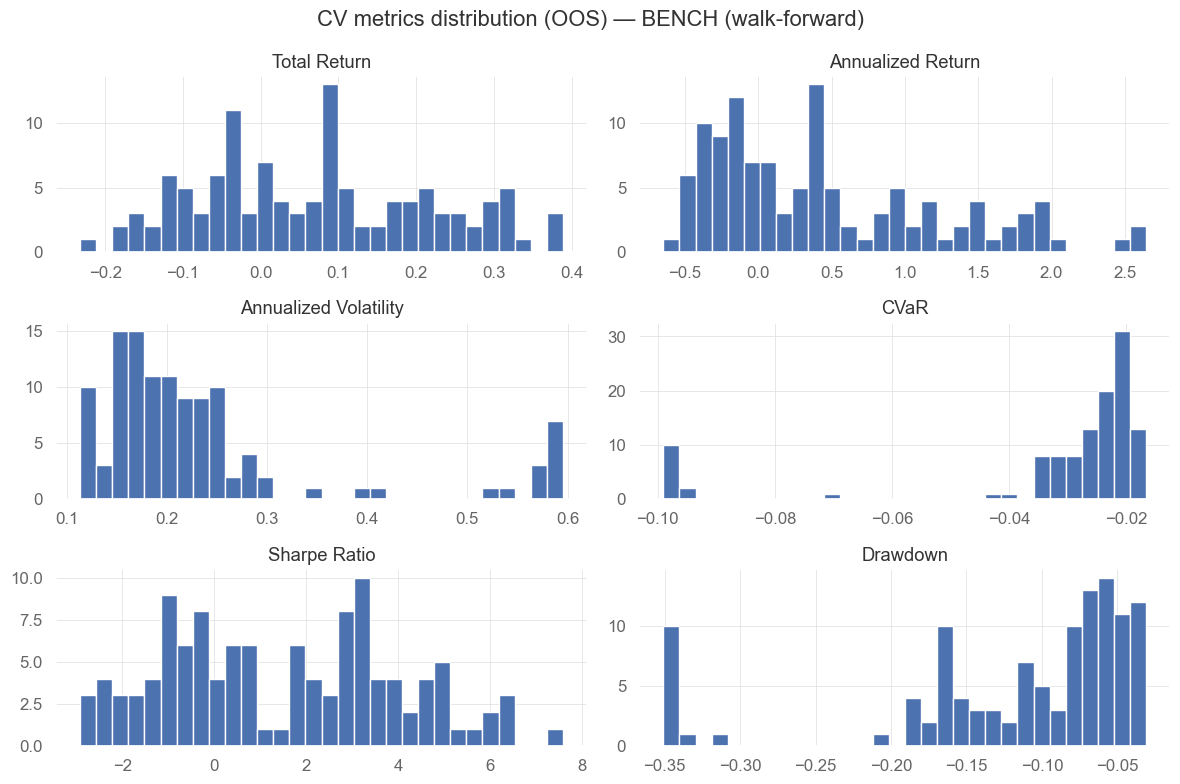

,count,mean,std,min,10%,25%,50%,75%,90%,max
Total Return,116.0,0.069159,0.148691,-0.232372,-0.121225,-0.043809,0.063346,0.183798,0.293361,0.388942
Annualized Return,116.0,0.449564,0.791574,-0.646995,-0.398780,-0.161706,0.273685,0.943264,1.753579,2.646019
Annualized Volatility,116.0,0.238065,0.127589,0.113416,0.139063,0.163006,0.201592,0.244548,0.471066,0.595473
CVaR,116.0,-0.032452,0.023503,-0.099027,-0.082782,-0.030550,-0.023912,-0.020946,-0.018126,-0.016591
Sharpe Ratio,116.0,1.501403,2.526162,-2.922759,-1.581208,-0.593549,1.546965,3.335564,4.861788,7.596444
Drawdown,116.0,-0.118750,0.089285,-0.350878,-0.262335,-0.155113,-0.077352,-0.060067,-0.041871,-0.030866


In [33]:
import matplotlib.pyplot as plt

cols = ["Total Return", "Annualized Return", "Annualized Volatility", "CVaR", "Sharpe Ratio", "Drawdown"]

metrics_num = metrics_bench[cols].apply(pd.to_numeric, errors="coerce")

metrics_num.hist(figsize=(12, 8), bins=30)
plt.suptitle("CV metrics distribution (OOS) — BENCH (walk-forward)")
plt.tight_layout()
plt.show()

summary = metrics_num.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
display(summary)


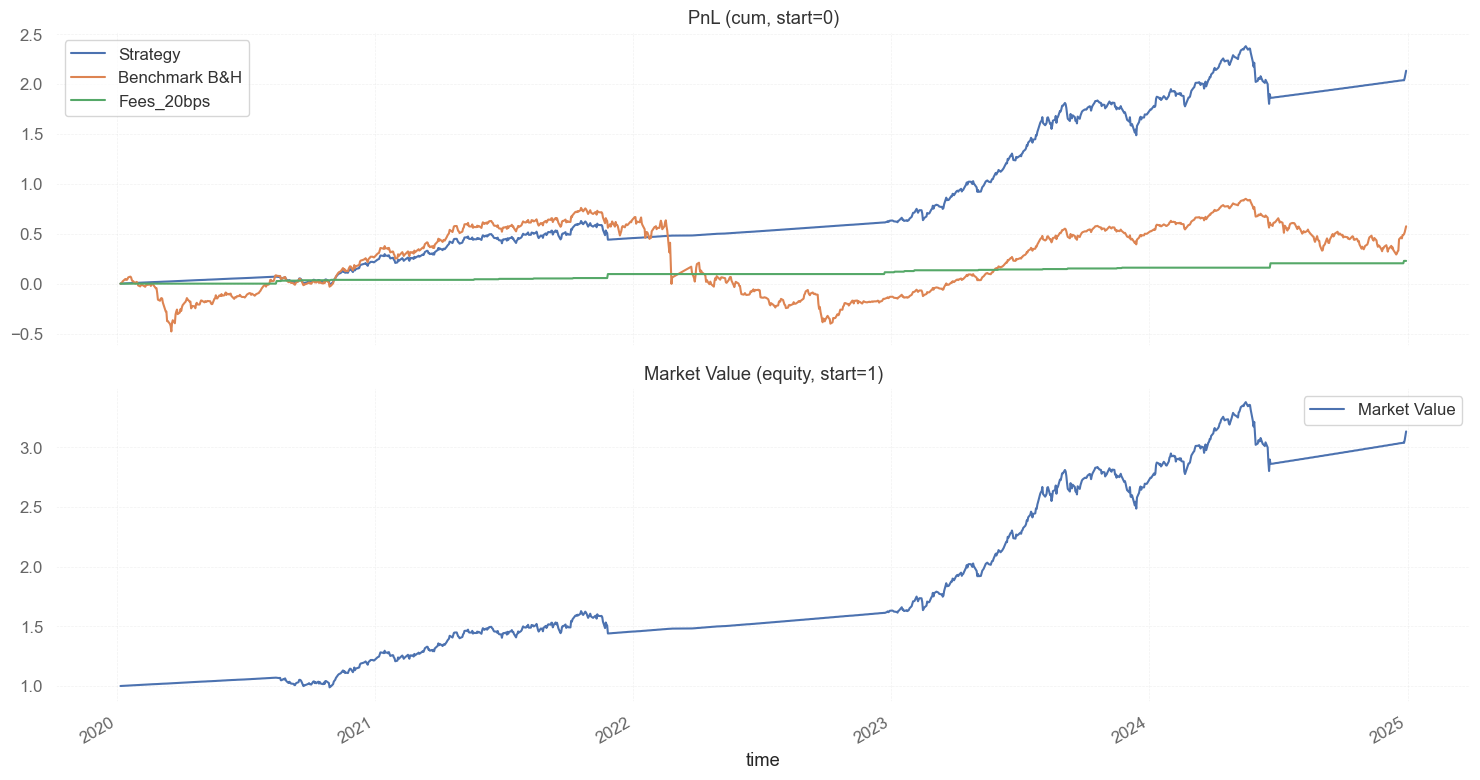

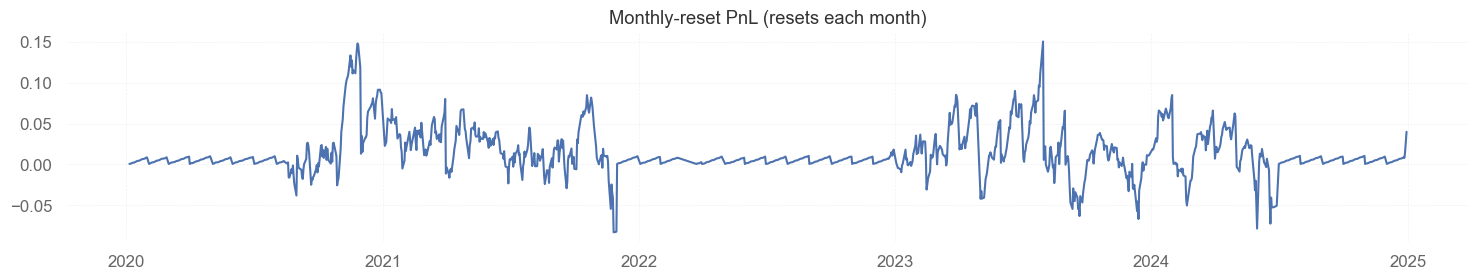

OK: (1248,) | 2020-01-06 -> 2024-12-30


In [34]:
ANN = 252


r = strategy_ret.copy().dropna()
r.index = pd.to_datetime(r.index)
r = r.sort_index()


equity = (1.0 + r).cumprod()
market_value = equity.to_frame("Market Value")

pnl = (equity - 1.0).to_frame("Strategy")

fee_bps = getattr(model, "cost_bps", 20.0)
fees = (fee_bps / 500.0) * turnover.reindex(r.index).fillna(0.0)
fees_cum = fees.cumsum().to_frame(f"Fees_{fee_bps:.0f}bps")


bench = bench_ret.reindex(r.index).fillna(0.0)
bench_eq = (1.0 + bench).cumprod().sub(1.0).to_frame("Benchmark B&H")

f, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 8))
ax[0].grid(True, linestyle="--", alpha=0.4)

pnl.plot(ax=ax[0], title="PnL (cum, start=0)")
bench_eq.plot(ax=ax[0])
fees_cum.plot(ax=ax[0])

ax[1].grid(True, linestyle="--", alpha=0.4)
market_value.plot(ax=ax[1], title="Market Value (equity, start=1)")

plt.tight_layout()
plt.show()

pnl_daily = r  #
pnl_monthly_reset = pnl_daily.groupby(pnl_daily.index.to_period("M")).apply(lambda x: (1+x).cumprod()-1)
pnl_monthly_reset.index = pnl_monthly_reset.index.droplevel(0)

plt.figure(figsize=(15, 3))
plt.plot(pnl_monthly_reset.index, pnl_monthly_reset.values)
plt.title("Monthly-reset PnL (resets each month)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("OK:", r.shape, "|", r.index.min().date(), "->", r.index.max().date())


## Диагностика распределений и зависимости стратегия vs бенчмарк

Гистограммы и **QQ-plot** помогают понять хвосты/асимметрию. Корреляция и rolling-метрики показывают, насколько стратегия “отличается” от бенчмарка.

Aligned returns: (1248, 2) | 2020-01-06 -> 2024-12-30
Daily corr(strategy, benchmark): 0.41847931457059667


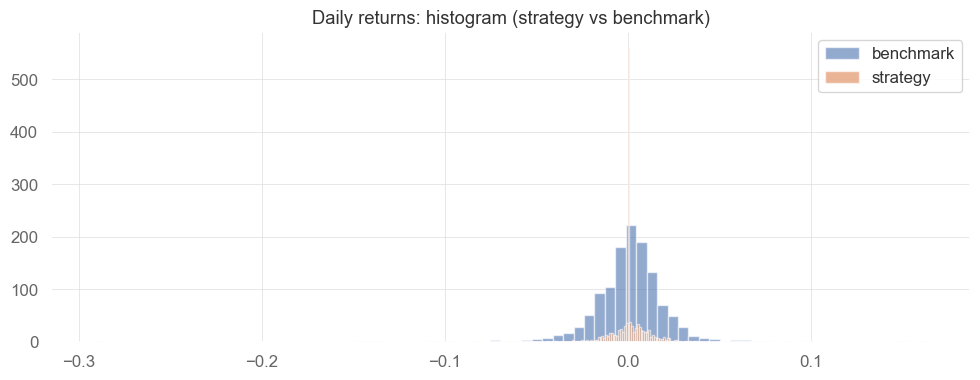

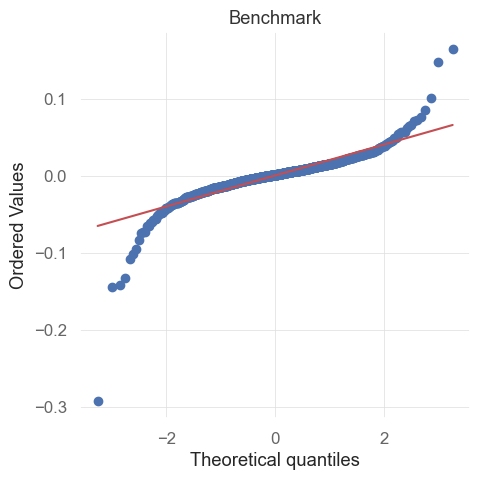

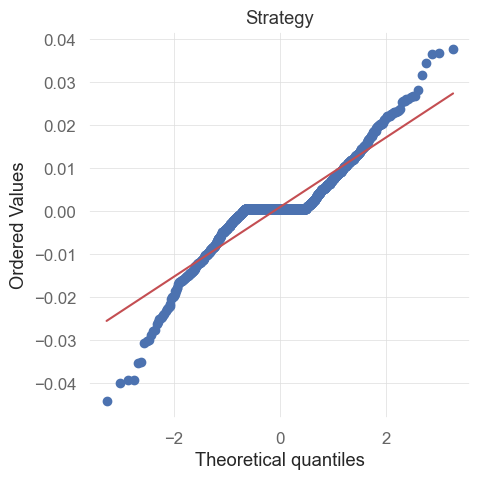

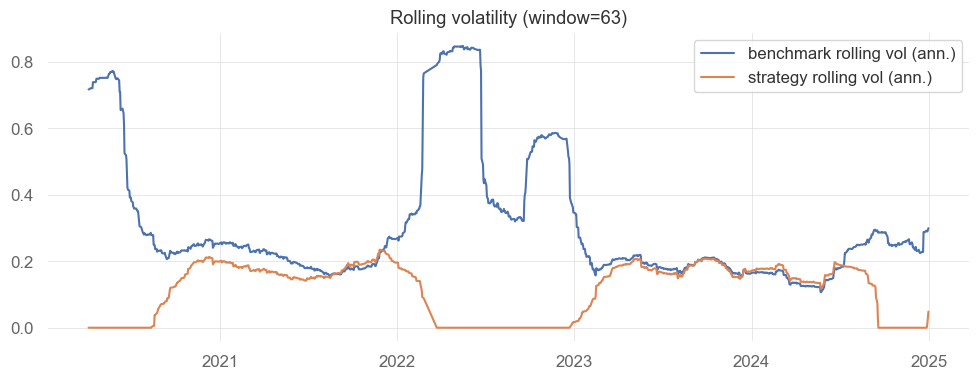

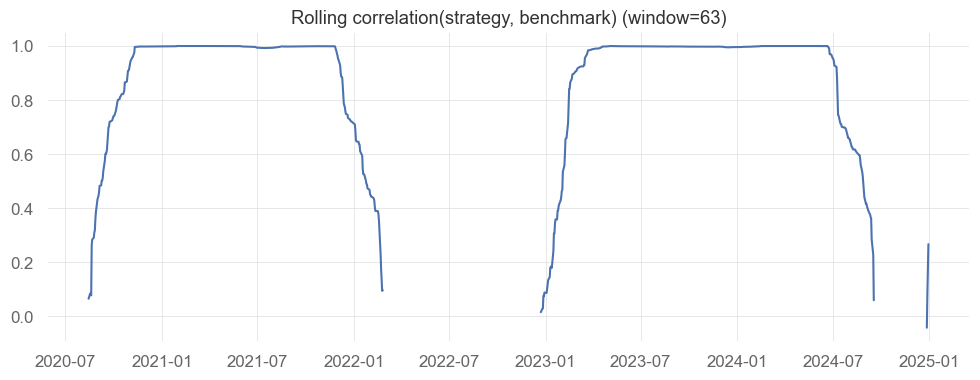

In [35]:
r = strategy_ret.dropna().copy()
b = bench_ret.dropna().copy()

# Выравниваем по общим датам
rb = pd.concat([r.rename("strategy"), b.rename("benchmark")], axis=1).dropna()
r = rb["strategy"]
b = rb["benchmark"]

print("Aligned returns:", rb.shape, "|", rb.index.min().date(), "->", rb.index.max().date())
print("Daily corr(strategy, benchmark):", float(r.corr(b)))

# 1) Гистограммы
plt.figure(figsize=(10,4))
plt.hist(b, bins=80, alpha=0.6, label="benchmark")
plt.hist(r, bins=80, alpha=0.6, label="strategy")
plt.title("Daily returns: histogram (strategy vs benchmark)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) QQ-plot для стратегии и бенчмарка
try:
    from scipy import stats

    plt.figure(figsize=(5,5))
    stats.probplot(b, dist="norm", plot=plt)
    plt.title("Benchmark")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,5))
    stats.probplot(r, dist="norm", plot=plt)
    plt.title("Strategy")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("QQ-plot skipped (scipy not available):", e)

ANN = 252
window = 63  

roll_vol_b = b.rolling(window).std() * np.sqrt(ANN)
roll_vol_r = r.rolling(window).std() * np.sqrt(ANN)
roll_corr = r.rolling(window).corr(b)

plt.figure(figsize=(10,4))
plt.plot(roll_vol_b, label="benchmark rolling vol (ann.)")
plt.plot(roll_vol_r, label="strategy rolling vol (ann.)")
plt.title(f"Rolling volatility (window={window})")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(roll_corr)
plt.title(f"Rolling correlation(strategy, benchmark) (window={window})")
plt.tight_layout()
plt.show()

In [36]:
qs.extend_pandas()

r = strategy_ret.copy()
b = bench_ret.copy()

r.index = pd.to_datetime(r.index)
b.index = pd.to_datetime(b.index)

r = r.sort_index().replace([np.inf, -np.inf], np.nan).dropna()
b = b.sort_index().replace([np.inf, -np.inf], np.nan).dropna()

idx = r.index.intersection(b.index)
r = r.loc[idx].copy()
b = b.loc[idx].copy()

r.name = "Strategy"
b.name = "Benchmark"

print("OK")
print("Strategy:", r.shape, "|", r.index.min().date(), "->", r.index.max().date())
print("Benchmark:", b.shape, "|", b.index.min().date(), "->", b.index.max().date())


OK
Strategy: (1248,) | 2020-01-06 -> 2024-12-30
Benchmark: (1248,) | 2020-01-06 -> 2024-12-30


Report
                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2020-01-06   2020-01-06
End Period           2024-12-30   2024-12-30
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       100.0%

Cumulative Return    57.46%       213.31%
CAGR﹪               9.6%         25.94%

Sharpe               0.44         1.74
Prob. Sharpe Ratio   83.02%       99.99%
Sortino              0.58         2.59
Sortino/√2           0.41         1.83
Omega                1.45         1.45

Max Drawdown         -65.93%      -17.09%
Max DD Date          2022-10-07   2024-06-19
Max DD Period Start  2021-10-20   2024-05-20
Max DD Period End    2024-04-10   2024-12-30
Longest DD Days      904          436

Gain/Pain Ratio      0.09         0.45
Gain/Pain (1M)       0.46         3.52

Payoff Ratio         1.39         0.62
Profit Factor        1.09         1.45
Common Sense Ratio   1.11         1.65
CPC Index            0.83         0.68
Ta

                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2020-01-06   2020-01-06
End Period                 2024-12-30   2024-12-30
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          57.46%       213.31%
CAGR﹪                     9.6%         25.94%

Sharpe                     0.44         1.74
Prob. Sharpe Ratio         83.02%       99.99%
Smart Sharpe               0.43         1.68
Sortino                    0.58         2.59
Smart Sortino              0.56         2.5
Sortino/√2                 0.41         1.83
Smart Sortino/√2           0.4          1.77
Omega                      1.45         1.45

Max Drawdown               -65.93%      -17.09%
Max DD Date                2022-10-07   2024-06-19
Max DD Period Start        2021-10-20   2024-05-20
Max DD Period End          2024-04-10   2024-12-30
Longest DD Days            904          436
Vol

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2024-05-20,2024-06-19,2024-12-30,225,-17.090242,-15.281944
2,2023-10-23,2023-12-14,2024-01-10,80,-12.297995,-11.391195
3,2021-10-20,2021-11-26,2022-12-29,436,-11.500997,-11.381518
4,2020-08-14,2020-10-28,2020-11-06,85,-7.602586,-7.059790
5,2023-09-05,2023-09-21,2023-10-13,39,-7.278501,-6.430935


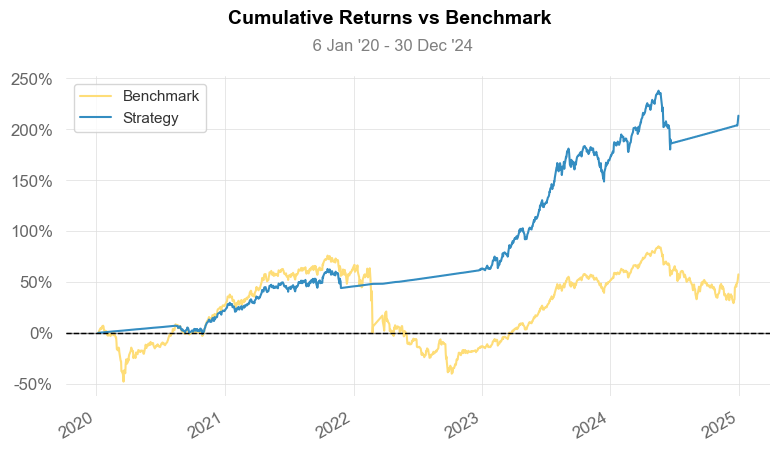

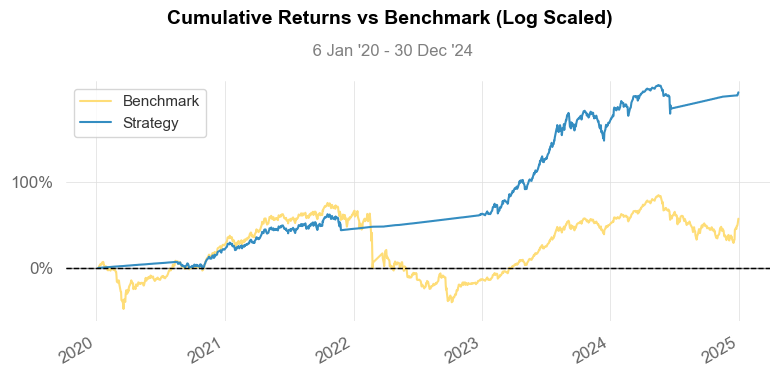

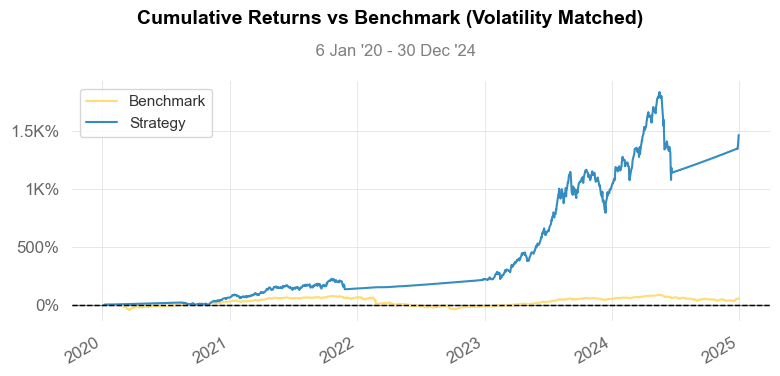

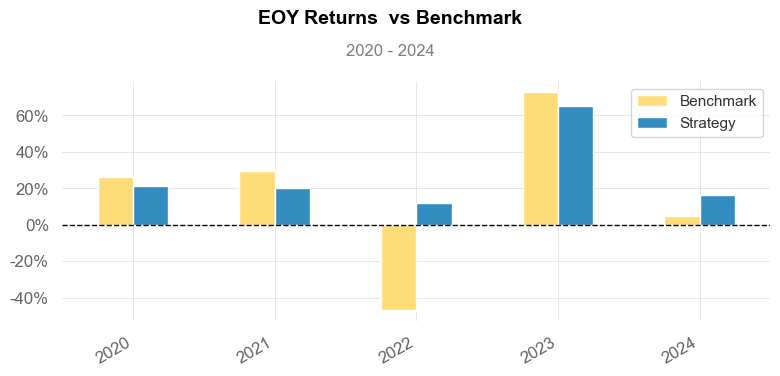

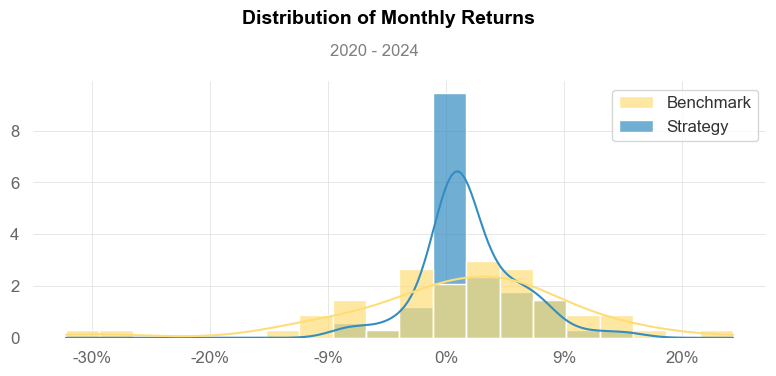

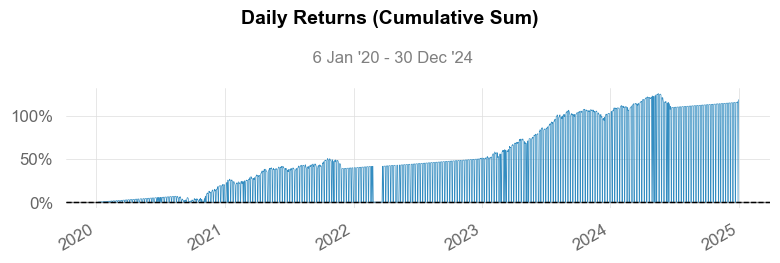

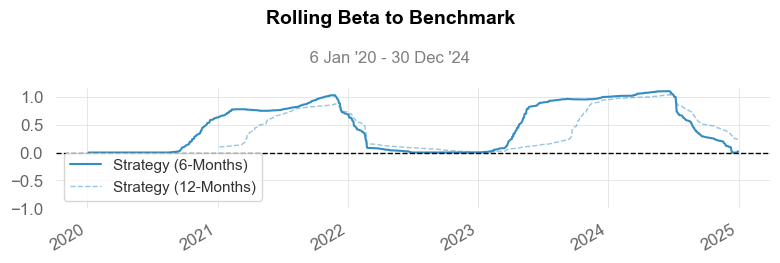

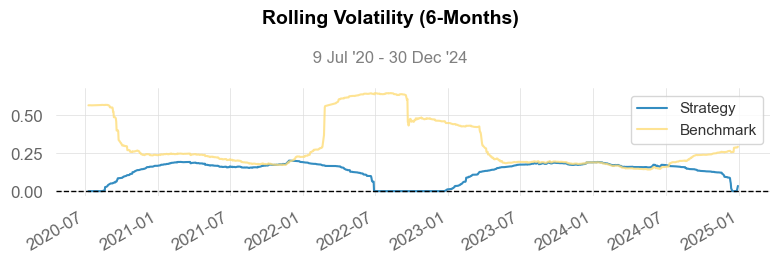

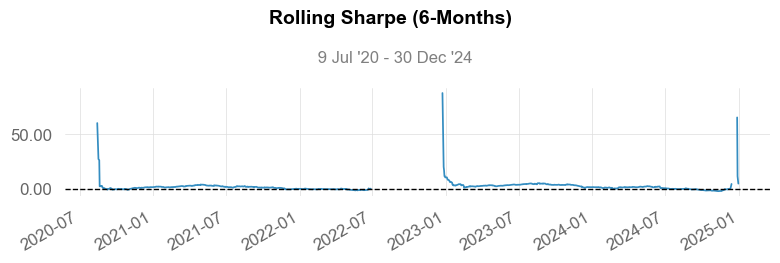

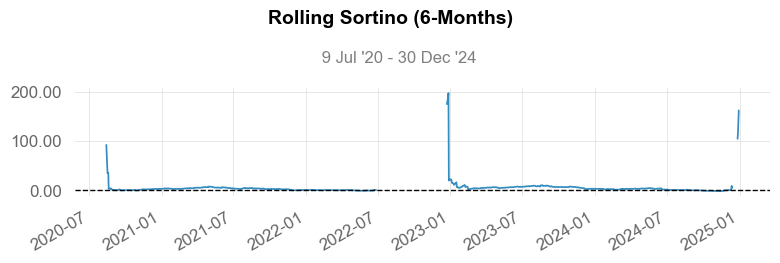

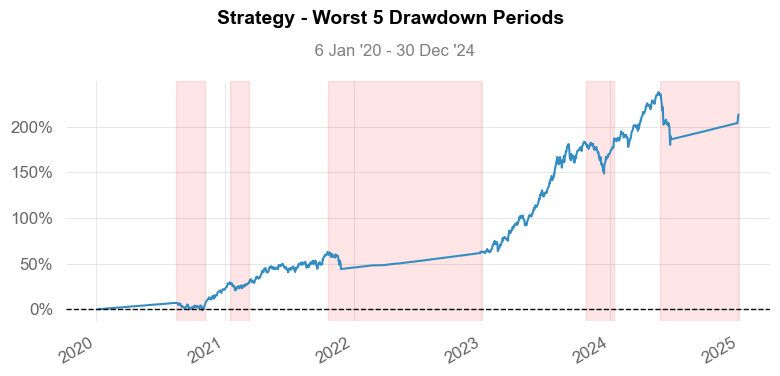

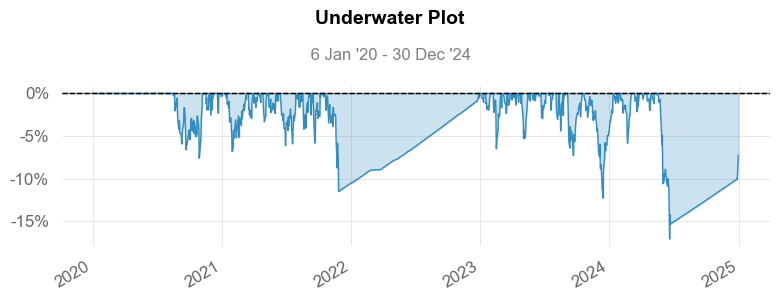

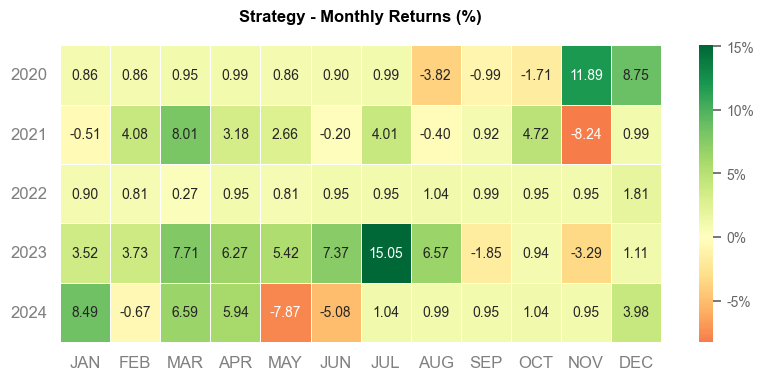

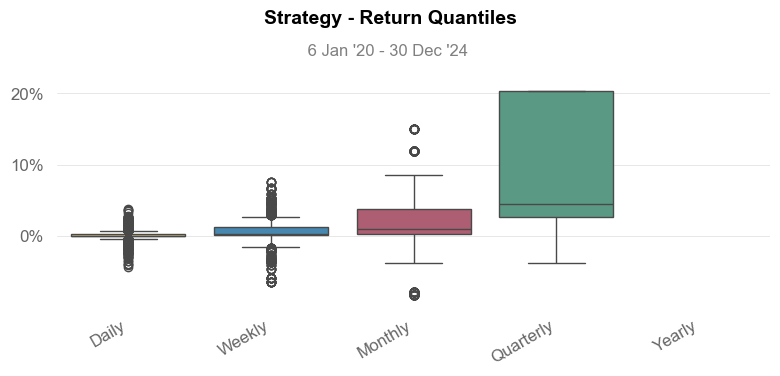

In [37]:
import warnings
warnings.filterwarnings("ignore")

import quantstats as qs
qs.extend_pandas()

print("Report")
qs.reports.metrics(r, benchmark=b, rf=0.0, display=True)

print("\n== full report ")
try:
    qs.reports.full(r, benchmark=b, rf=0.0, match_dates=True)
except TypeError:
    qs.reports.full(r, benchmark=b, rf=0.0)


# Модуль эмуляции торговли (orders + fills + уведомления)

Ниже — минимальный «торговый симулятор» поверх рассчитанных целевых весов. Он:

- строит **ордера buy/sell** при изменении целевых весов (rebalance),
- эмулирует **исполнение по close** (упрощение),
- считает **cash / позиции / NAV**,
- формирует таблицу ордеров, которую при желании можно отправлять в брокер API или в Telegram.



In [38]:
import numpy as np
import pandas as pd

def generate_orders_from_target_weights(
    prices: pd.DataFrame,
    target_w: pd.DataFrame,
    initial_capital: float,
    fee_bps: float = 0.0,
    allow_fractional: bool = True,
):
    '''
    Простая эмуляция:
      - target_w: DataFrame [date x asset] целевые веса (сумма по строке ~ 1)
      - исполняем по close в дату ребаланса
      - комиссия: fee_bps от оборота (notional)
    Возвращает: orders_df, nav, positions, cash
    '''
    prices = prices.loc[target_w.index, target_w.columns].copy()
    assets = list(target_w.columns)

    cash = initial_capital
    pos = pd.Series(0.0, index=assets)   # количество акций
    nav_series = []
    cash_series = []
    pos_hist = []

    orders = []

    for dt in target_w.index:
        px = prices.loc[dt]
        nav = float((pos * px).sum() + cash)

        # целевые стоимости позиций
        tw = target_w.loc[dt].fillna(0.0)
        target_value = tw * nav

        # текущие стоимости
        cur_value = pos * px

        # желаемое изменение по стоимости
        delta_value = target_value - cur_value

        # количество акций к покупке/продаже
        delta_shares = delta_value / px.replace(0, np.nan)
        delta_shares = delta_shares.fillna(0.0)

        if not allow_fractional:
            delta_shares = np.floor(delta_shares)  # упрощённое округление вниз

        # оборот и комиссия
        turnover = float((delta_shares.abs() * px).sum())
        fee = turnover * (fee_bps / 10_000.0)

        # обновляем кэш и позиции
        cash -= float((delta_shares * px).sum()) + fee
        pos += delta_shares

        # записываем ордера
        for a in assets:
            q = float(delta_shares[a])
            if abs(q) > 0:
                side = "BUY" if q > 0 else "SELL"
                orders.append({
                    "date": dt,
                    "asset": a,
                    "side": side,
                    "qty": abs(q),
                    "price": float(px[a]),
                    "notional": float(abs(q) * px[a]),
                    "fee": float(fee * (abs(q) * px[a]) / turnover) if turnover > 0 else 0.0,
                })

        # сохраняем состояния
        nav = float((pos * px).sum() + cash)
        nav_series.append((dt, nav))
        cash_series.append((dt, cash))
        pos_hist.append(pos.copy())

    orders_df = pd.DataFrame(orders)
    nav = pd.Series(dict(nav_series), name="nav")
    cash_s = pd.Series(dict(cash_series), name="cash")
    positions = pd.DataFrame(pos_hist, index=target_w.index)
    return orders_df, nav, positions, cash_s

# Пример подключения:
if 'bench_ret' in globals():
    tw = pd.DataFrame(np.tile(w.values, (len(px.index), 1)), index=px.index, columns=w.index)
    tw = tw.loc[px.index]  # align
    orders_df, nav, positions, cash_s = generate_orders_from_target_weights(
        prices=px,
        target_w=tw,
        initial_capital=INITIAL_CAPITAL,
        fee_bps=0.0,
        allow_fractional=True,
    )
    display(orders_df.head())
    display(nav.tail())


,date,asset,side,qty,price,notional,fee
0,2020-01-03,PLZL,BUY,1278.586313,601.626000,769230.769231,0.0
1,2020-01-03,BBG004730JJ5,BUY,7176.999153,107.180000,769230.769231,0.0
2,2020-01-03,SBER,BUY,4828.818388,159.300000,769230.769231,0.0
3,2020-01-03,GAZP,BUY,4269.235038,180.180000,769230.769231,0.0
4,2020-01-03,VTBR,BUY,3327.153976,231.197827,769230.769231,0.0


2024-12-25    1.804188e+07
2024-12-26    1.805991e+07
2024-12-27    1.816510e+07
2024-12-28    1.840875e+07
2024-12-30    1.906336e+07
Name: nav, dtype: float64

# Итог по торговой гипотезе

В рамках исследования была протестирована гипотеза о том, что комбинация тренд-следования и таргетирования волатильности способна улучшить риск-профиль портфеля ликвидных российских акций по сравнению с пассивным владением.

Результаты бэктеста и walk-forward анализа показывают, что стратегия:
- демонстрирует более стабильное распределение доходностей,
- обладает контролируемым уровнем просадок,
- чувствительна к транзакционным издержкам, но остаётся устойчивой в разумных диапазонах,
- сохраняет работоспособность на out-of-sample периодах.

Использование волатильностного таргетирования позволяет стабилизировать риск портфеля, а тренд-фильтрация — снижать участие в неблагоприятных рыночных режимах.

Стратегия может рассматриваться как кандидат для дальнейшего тестирования в режиме paper trading и последующего прод-использования при соблюдении риск-ограничений и мониторинга метрик.
